In [ ]:
""" [1] Imports & config
Load tips, derive tip_pct, and declare module-level constants.
Clustering is restricted to behavioral variables (total_bill, tip_pct, size);
demographic columns are reserved for post-hoc profiling only.
"""
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

PLOT_DIR = Path(__file__).parent / "plots"
PLOT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 41
CLUSTER_FEATURES = ["total_bill", "tip_pct", "size"]
DEMO_COLS = ["sex", "smoker", "time", "day"]

tips = sns.load_dataset("tips")
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100

print(f"Shape: {tips.shape}")
print(f"tip_pct  mean={tips['tip_pct'].mean():.1f}%  std={tips['tip_pct'].std():.1f}%  range={tips['tip_pct'].min():.1f}–{tips['tip_pct'].max():.1f}%")

Shape: (244, 8)
tip_pct  mean=16.1%  std=6.1%  range=3.6–71.0%


In [ ]:
""" [2] Standardise clustering features
K-means distances are Euclidean, so features with larger numeric ranges dominate.
StandardScaler centres and scales each feature to mean=0, std=1 before clustering.
"""
scaler = StandardScaler()
X = scaler.fit_transform(tips[CLUSTER_FEATURES])

print("Post-scaling means (expect ≈ 0):", X.mean(axis=0).round(3))
print("Post-scaling stds  (expect ≈ 1):", X.std(axis=0).round(3))

Post-scaling means (expect ≈ 0): [-0.  0. -0.]
Post-scaling stds  (expect ≈ 1): [1. 1. 1.]


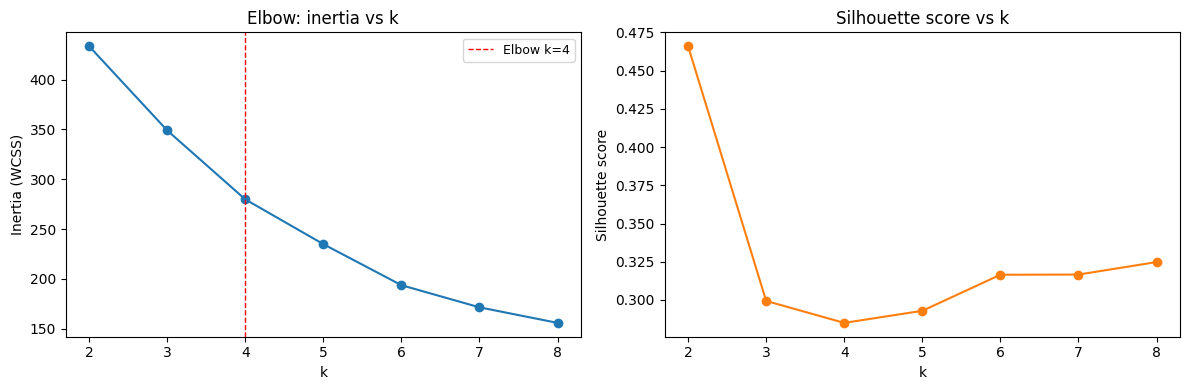

Saved: c:\Users\ACER\Documents\GitHub\ds-ml-code-reading\cases\seaborn_tips\plots\kmeans_tips_elbow.png
Elbow at k=4  (inertia=279.8)
Peak silhouette at k=2  (score=0.466)


In [ ]:
""" [3] Select k — elbow and silhouette plots
Elbow: inertia (within-cluster sum of squares) drops fast then flattens — pick the bend.
Elbow k is found via the kneedle heuristic: normalise both axes to [0, 1] and take the point farthest below the line connecting the first and last inertia values.
Silhouette: how much closer each point is to its own cluster than to the nearest other; +1 = well separated, 0 = borderline.  Its peak independently cross-checks the elbow.
"""
K_RANGE = range(2, 9)
inertias: list[float] = []
sil_scores: list[float] = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

ks = list(K_RANGE)
x_norm = np.linspace(0, 1, len(ks))
y_norm = (np.array(inertias) - inertias[-1]) / (inertias[0] - inertias[-1])
best_elbow_k = ks[int(np.argmax(1 - x_norm - y_norm))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker="o")
axes[0].axvline(best_elbow_k, color="red", linestyle="--", linewidth=1, label=f"Elbow k={best_elbow_k}")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow: inertia vs k")

axes[1].plot(list(K_RANGE), sil_scores, marker="o", color="tab:orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score vs k")

fig.tight_layout()
fig.savefig(PLOT_DIR / "kmeans_tips_elbow.png")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_elbow.png'}")
print(f"Elbow at k={best_elbow_k}  (inertia={inertias[best_elbow_k - 2]:.1f})")
best_sil_k = int(np.argmax(sil_scores)) + 2   # +2 because K_RANGE starts at 2
print(f"Peak silhouette at k={best_sil_k}  (score={max(sil_scores):.3f})")

In [ ]:
""" [4] Fit final model — k from silhouette peak k is set to the silhouette-optimal value found in cell [3].
n_init=10 re-starts with 10 random initialisations; KMeans keeps the lowest-inertia run.
"""
K = best_sil_k
km_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
tips["segment"] = km_final.fit_predict(X)

seg_counts = tips["segment"].value_counts().sort_index().to_dict()
print(f"Segment sizes: {seg_counts}")
print(f"Inertia: {km_final.inertia_:.1f}   Silhouette: {silhouette_score(X, tips['segment']):.3f}")

Segment sizes: {0: 178, 1: 66}
Inertia: 433.7   Silhouette: 0.466


NameError: name 'centers_raw' is not defined

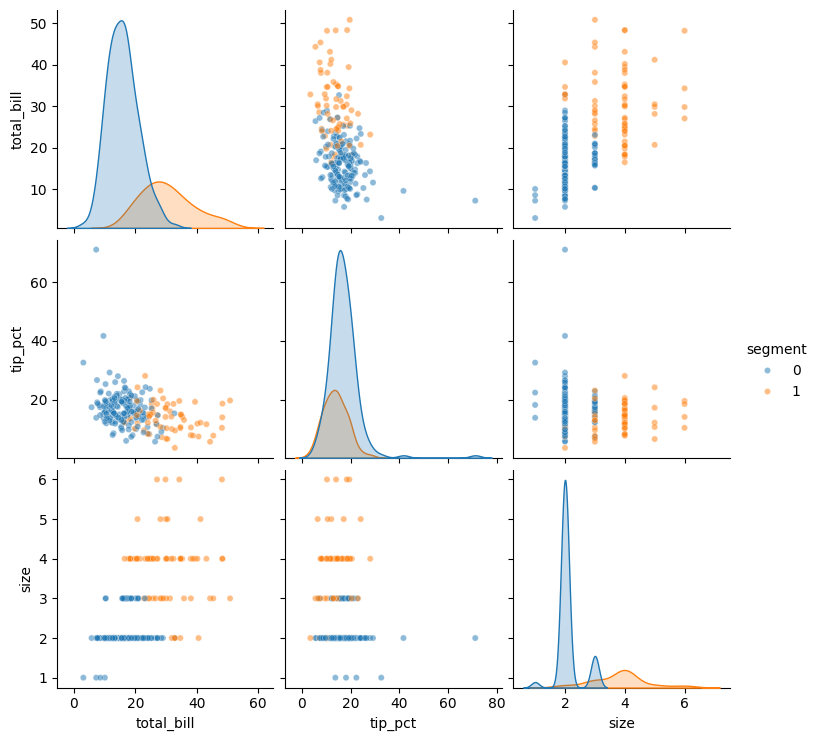

In [ ]:
""" [6] Pairplot — all feature pairs coloured by segment
Clustering used three features; a single 2D scatter would silently drop one axis,
making clusters look better or worse separated than they actually are.
The pairplot shows all three pairwise projections; stars mark cluster centres.
"""
palette = sns.color_palette("tab10", K)

pair_df = tips[CLUSTER_FEATURES + ["segment"]].assign(segment=lambda d: d["segment"].astype(str))
palette_str = {str(i): palette[i] for i in range(K)}
g = sns.pairplot(pair_df, hue="segment", palette=palette_str,
                 plot_kws={"alpha": 0.5, "s": 20}, diag_kind="kde")

for i in range(len(CLUSTER_FEATURES)):
    for j in range(len(CLUSTER_FEATURES)):
        if i != j:
            for seg in range(K):
                g.axes[i, j].scatter(
                    centers_raw[seg, j], centers_raw[seg, i],
                    marker="*", s=200, color=palette[seg],
                    edgecolors="black", linewidths=0.7, zorder=5,
                )

g.figure.suptitle(f"Diner segments — all feature pairs  (k={K})", y=1.02)
g.figure.savefig(PLOT_DIR / "kmeans_tips_segments.png", bbox_inches="tight")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_segments.png'}")

In [ ]:
""" [7] Demographic breakdown per segment
Normalised crosstabs reveal the proportion of each category value within each segment.
K-means saw none of these variables — any demographic skew is a discovery, not an artefact.
"""
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), DEMO_COLS):
    ct = pd.crosstab(tips["segment"], tips[col], normalize="index")
    ct.plot(kind="bar", ax=ax, legend=True, rot=0)
    ax.legend(title=col, fontsize=8, title_fontsize=8)
    ax.set_title(col)
    ax.set_xlabel("Segment")
    ax.set_ylabel("Proportion")

fig.suptitle("Demographic mix by segment  (k-means used no demographic features)", fontsize=12)
fig.tight_layout()
fig.savefig(PLOT_DIR / "kmeans_tips_demographics.png")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_demographics.png'}")
dominant = pd.DataFrame(
    {col: pd.crosstab(tips["segment"], tips[col], normalize="index").idxmax(axis=1)
     for col in DEMO_COLS}
).T.rename(columns=lambda s: f"seg{s}")
print("\nDominant category per segment:")
print(dominant.to_string())

: 

In [ ]:
""" [8] Silhouette plot — per-sample fit quality
Each horizontal bar shows how well a sample fits its cluster vs the next-closest cluster.
Score near +1: well inside its cluster.  Near 0: on the boundary.  Negative: likely misassigned.
The dashed line marks the mean silhouette — a useful scalar for comparing k values.
"""
sil_vals = silhouette_samples(X, tips["segment"])
y_lower = 10

fig, ax = plt.subplots(figsize=(7, 5))
for seg in range(K):
    seg_sil = np.sort(sil_vals[tips["segment"] == seg])
    y_upper = y_lower + len(seg_sil)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, seg_sil,
        alpha=0.7, label=f"Segment {seg}", color=palette[seg],
    )
    y_lower = y_upper + 5

mean_sil = float(silhouette_score(X, tips["segment"]))
ax.axvline(mean_sil, color="red", linestyle="--", linewidth=1.2, label=f"Mean = {mean_sil:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by segment)")
ax.set_title(f"Silhouette analysis  (k={K})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "kmeans_tips_silhouette.png")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_silhouette.png'}")
print(f"Mean silhouette: {mean_sil:.3f}  (0 = random assignment, 1 = perfect separation)")

: 

In [ ]:
""" [5] Segment profiles — cluster centres in original units
Invert the cluster centres from scaled to original units for interpretability.
Each row is a diner archetype: the numbers answer "who spends how much and tips how generously?"
"""
centers_raw = scaler.inverse_transform(km_final.cluster_centers_)
profile = pd.DataFrame(centers_raw, columns=CLUSTER_FEATURES)
profile["tip_mean"] = tips.groupby("segment")["tip"].mean().sort_index().values
profile.index.name = "segment"

print("\nSegment profiles (cluster centres, original scale):")
print(profile.round(2).to_string())


Segment profiles (cluster centres, original scale):
         total_bill  tip_pct  size  tip_mean
segment                                     
0             15.85    16.93  2.11      2.59
1             30.40    13.80  3.82      4.10


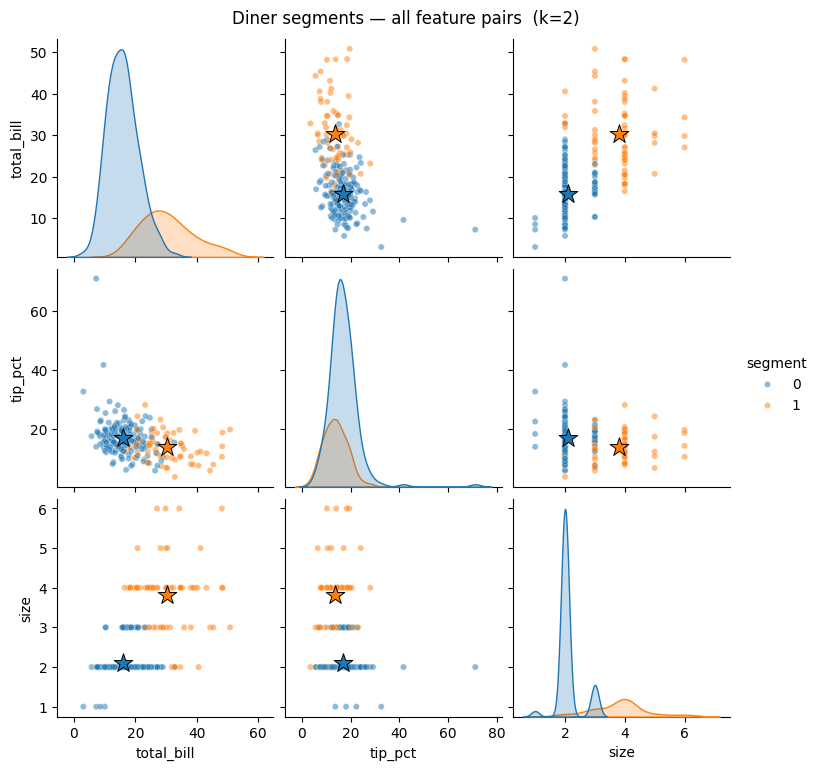

Saved: c:\Users\ACER\Documents\GitHub\ds-ml-code-reading\cases\seaborn_tips\plots\kmeans_tips_segments.png


In [ ]:
""" [6] Pairplot — all feature pairs coloured by segment
Clustering used three features; a single 2D scatter would silently drop one axis,
making clusters look better or worse separated than they actually are.
The pairplot shows all three pairwise projections; stars mark cluster centres.
"""
palette = sns.color_palette("tab10", K)

pair_df = tips[CLUSTER_FEATURES + ["segment"]].assign(segment=lambda d: d["segment"].astype(str))
palette_str = {str(i): palette[i] for i in range(K)}
g = sns.pairplot(pair_df, hue="segment", palette=palette_str,
                 plot_kws={"alpha": 0.5, "s": 20}, diag_kind="kde")

for i in range(len(CLUSTER_FEATURES)):
    for j in range(len(CLUSTER_FEATURES)):
        if i != j:
            for seg in range(K):
                g.axes[i, j].scatter(
                    centers_raw[seg, j], centers_raw[seg, i],
                    marker="*", s=200, color=palette[seg],
                    edgecolors="black", linewidths=0.7, zorder=5,
                )

g.figure.suptitle(f"Diner segments — all feature pairs  (k={K})", y=1.02)
g.figure.savefig(PLOT_DIR / "kmeans_tips_segments.png", bbox_inches="tight")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_segments.png'}")

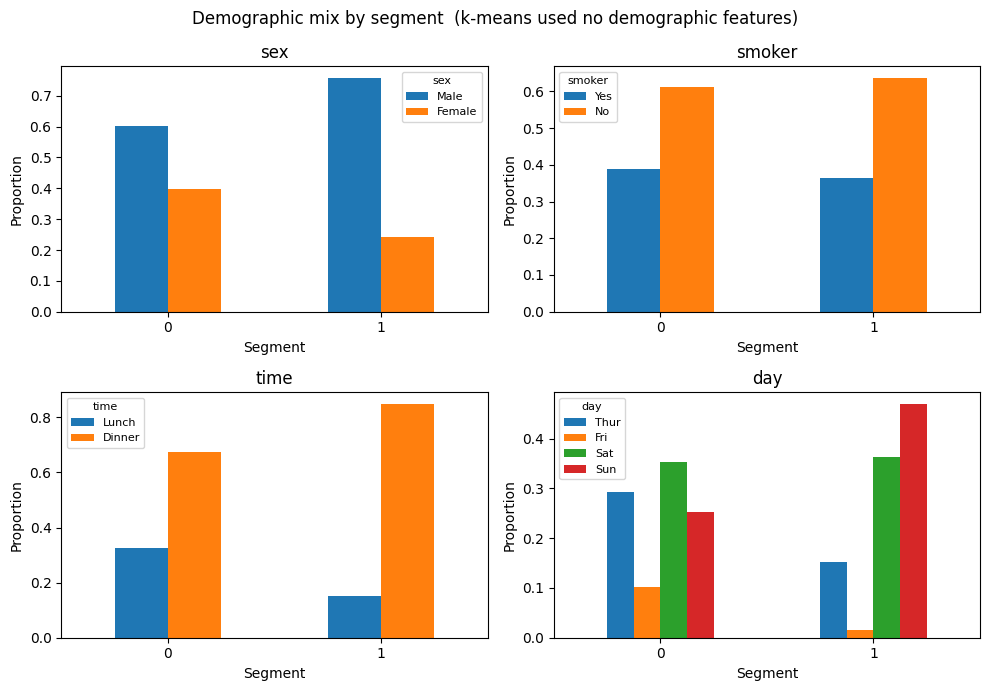

Saved: c:\Users\ACER\Documents\GitHub\ds-ml-code-reading\cases\seaborn_tips\plots\kmeans_tips_demographics.png

Dominant category per segment:
segment    seg0    seg1
sex        Male    Male
smoker       No      No
time     Dinner  Dinner
day         Sat     Sun


In [ ]:
""" [7] Demographic breakdown per segment
Normalised crosstabs reveal the proportion of each category value within each segment.
K-means saw none of these variables — any demographic skew is a discovery, not an artefact.
"""
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), DEMO_COLS):
    ct = pd.crosstab(tips["segment"], tips[col], normalize="index")
    ct.plot(kind="bar", ax=ax, legend=True, rot=0)
    ax.legend(title=col, fontsize=8, title_fontsize=8)
    ax.set_title(col)
    ax.set_xlabel("Segment")
    ax.set_ylabel("Proportion")

fig.suptitle("Demographic mix by segment  (k-means used no demographic features)", fontsize=12)
fig.tight_layout()
fig.savefig(PLOT_DIR / "kmeans_tips_demographics.png")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_demographics.png'}")
dominant = pd.DataFrame(
    {col: pd.crosstab(tips["segment"], tips[col], normalize="index").idxmax(axis=1)
     for col in DEMO_COLS}
).T.rename(columns=lambda s: f"seg{s}")
print("\nDominant category per segment:")
print(dominant.to_string())

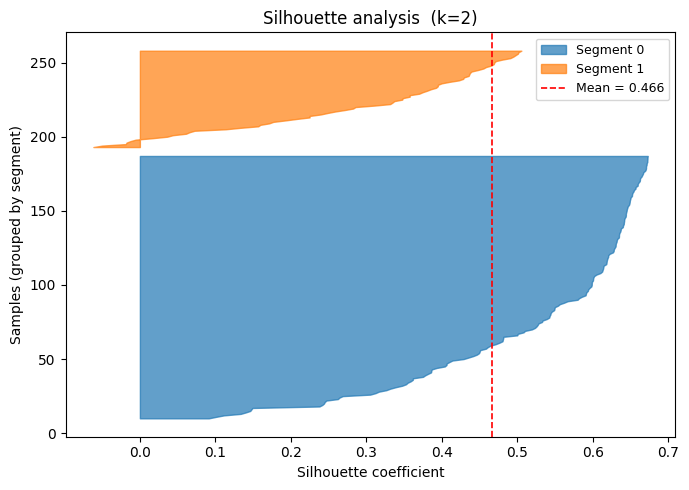

Saved: c:\Users\ACER\Documents\GitHub\ds-ml-code-reading\cases\seaborn_tips\plots\kmeans_tips_silhouette.png
Mean silhouette: 0.466  (0 = random assignment, 1 = perfect separation)


In [ ]:
""" [8] Silhouette plot — per-sample fit quality
Each horizontal bar shows how well a sample fits its cluster vs the next-closest cluster.
Score near +1: well inside its cluster.  Near 0: on the boundary.  Negative: likely misassigned.
The dashed line marks the mean silhouette — a useful scalar for comparing k values.
"""
sil_vals = silhouette_samples(X, tips["segment"])
y_lower = 10

fig, ax = plt.subplots(figsize=(7, 5))
for seg in range(K):
    seg_sil = np.sort(sil_vals[tips["segment"] == seg])
    y_upper = y_lower + len(seg_sil)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, seg_sil,
        alpha=0.7, label=f"Segment {seg}", color=palette[seg],
    )
    y_lower = y_upper + 5

mean_sil = float(silhouette_score(X, tips["segment"]))
ax.axvline(mean_sil, color="red", linestyle="--", linewidth=1.2, label=f"Mean = {mean_sil:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by segment)")
ax.set_title(f"Silhouette analysis  (k={K})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "kmeans_tips_silhouette.png")
plt.show()
print(f"Saved: {PLOT_DIR / 'kmeans_tips_silhouette.png'}")
print(f"Mean silhouette: {mean_sil:.3f}  (0 = random assignment, 1 = perfect separation)")